In [2]:
'''
Project Workflow
Implementing a customer segmentation project involves a systematic approach following the typical workflow of a machine learning project. Here’s a breakdown of the key steps:

Planning:-
Define the project scope, objectives, and success metrics.
Identify the stakeholders and assemble the project team.
Outline the project timeline and milestones.

Data Preparation:-
Data Collection: Gather customer data from various sources, including demographic information, purchase history, and interaction data.
Data Cleaning: Handle missing values, outliers, and inconsistencies to ensure the data is accurate and reliable.
Data Preprocessing: Transform and normalize the data to make it suitable for analysis. This may include encoding categorical variables and scaling numerical features.

Model Preparation:-
Exploratory Data Analysis (EDA): Conduct EDA to understand the distribution and relationships within the data. Use visualizations and statistical analyses to uncover initial patterns and insights.
Dimensionality Reduction: Apply techniques like Principal Component Analysis (PCA) to reduce the dimensionality of the data while preserving essential information, simplifying the data for clustering.
Clustering Algorithm Selection: Choose appropriate clustering algorithms such as K-Means, Hierarchical Clustering, and DBSCAN. Experiment with different algorithms to find the best fit for the data.
                                                                                                                                                                                        
Model Evaluation:-
Clustering Evaluation: Evaluate the performance of the clustering models using metrics like silhouette score, Davies-Bouldin index, and within-cluster sum of squares (WCSS) to ensure meaningful and well-defined segments.
Interpretation of Results: Analyze the clusters to ensure they make practical sense and align with business objectives. Refine the models as needed based on evaluation results.
                                                                                                                                                                                        
Model Deployment:-
Integration: Integrate the clustering model into the business processes, enabling real-time segmentation of new customers.
Implementation of Strategies: Use the segment profiles to design and implement targeted marketing campaigns, personalized customer interactions, and product development strategies.
                                                                                                                                                                                        
Monitoring and Maintenance:-
Performance Monitoring: Continuously monitor the performance of the clustering model and the effectiveness of the implemented strategies. Track key metrics such as customer engagement, satisfaction, and retention rates.
Model Updates: Regularly update the model with new data to ensure it remains accurate and relevant. Re-evaluate and refine the segmentation strategy as needed based on changing customer behaviors and business goals.
'''

'\nProject Workflow\nImplementing a customer segmentation project involves a systematic approach following the typical workflow of a machine learning project. Here’s a breakdown of the key steps:\n\nPlanning:-\nDefine the project scope, objectives, and success metrics.\nIdentify the stakeholders and assemble the project team.\nOutline the project timeline and milestones.\n\nData Preparation:-\nData Collection: Gather customer data from various sources, including demographic information, purchase history, and interaction data.\nData Cleaning: Handle missing values, outliers, and inconsistencies to ensure the data is accurate and reliable.\nData Preprocessing: Transform and normalize the data to make it suitable for analysis. This may include encoding categorical variables and scaling numerical features.\n\nModel Preparation:-\nExploratory Data Analysis (EDA): Conduct EDA to understand the distribution and relationships within the data. Use visualizations and statistical analyses to unco

In [4]:
'''
Understand the Approach: Customer Segmentation
Our approach to achieving the desired outcome would look something like this:

1. Data Collection and Preparation
Collect and preprocess customer data, ensuring it is clean and suitable for analysis. This may include demographic information, purchase history, and interaction data.

2. Exploratory Data Analysis (EDA)
Conduct EDA to understand the distribution and relationships within the data. Visualizations and statistical analyses will help uncover initial patterns and insights.

3. Dimensionality Reduction
Apply techniques like Principal Component Analysis (PCA) to reduce the dimensionality of the data while preserving essential information. This step helps in simplifying the data and improving the efficiency of clustering algorithms.

4. Clustering
Use clustering algorithms such as K-Means, Hierarchical Clustering, and DBSCAN to identify distinct customer segments. Evaluate and compare the performance of these algorithms using metrics like the silhouette score.

5. Segment Profiling
Analyze the characteristics of each segment to create detailed profiles. These profiles provide insights into the behaviors, preferences, and needs of each group.

6. Actionable Insights
Translate the segment profiles into actionable business strategies, such as targeted marketing campaigns, personalized service offerings, and strategic product development initiatives.


'''

'\nUnderstand the Approach: Customer Segmentation\nOur approach to achieving the desired outcome would look something like this:\n\n1. Data Collection and Preparation\nCollect and preprocess customer data, ensuring it is clean and suitable for analysis. This may include demographic information, purchase history, and interaction data.\n\n2. Exploratory Data Analysis (EDA)\nConduct EDA to understand the distribution and relationships within the data. Visualizations and statistical analyses will help uncover initial patterns and insights.\n\n3. Dimensionality Reduction\nApply techniques like Principal Component Analysis (PCA) to reduce the dimensionality of the data while preserving essential information. This step helps in simplifying the data and improving the efficiency of clustering algorithms.\n\n4. Clustering\nUse clustering algorithms such as K-Means, Hierarchical Clustering, and DBSCAN to identify distinct customer segments. Evaluate and compare the performance of these algorithms

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import plotly.express as px

In [12]:
import pandas as pd

df = pd.read_csv("C:/Users/91798/Desktop/DATA_ENGINEERING/Machine_Learning/Unsupervised/marketing_campaign.csv", sep='\t')
print(df.dtypes)     # Correct way to print column data types
print(df.info())     # Gives overview including non-null counts and data types


ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns 

In [14]:
## correlation coefficient heatmap
## outlier detection

# define numerical & categorical columns
columns = [column for column in df.columns if column != "ID"]
numeric_features = [feature for feature in columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 25 numerical features : ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

We have 3 categorical features : ['Education', 'Marital_Status', 'Dt_Customer']


In [16]:
##Data Cleaning
# Dropping constant value columns
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

KeyError: 'Z_CostContact'

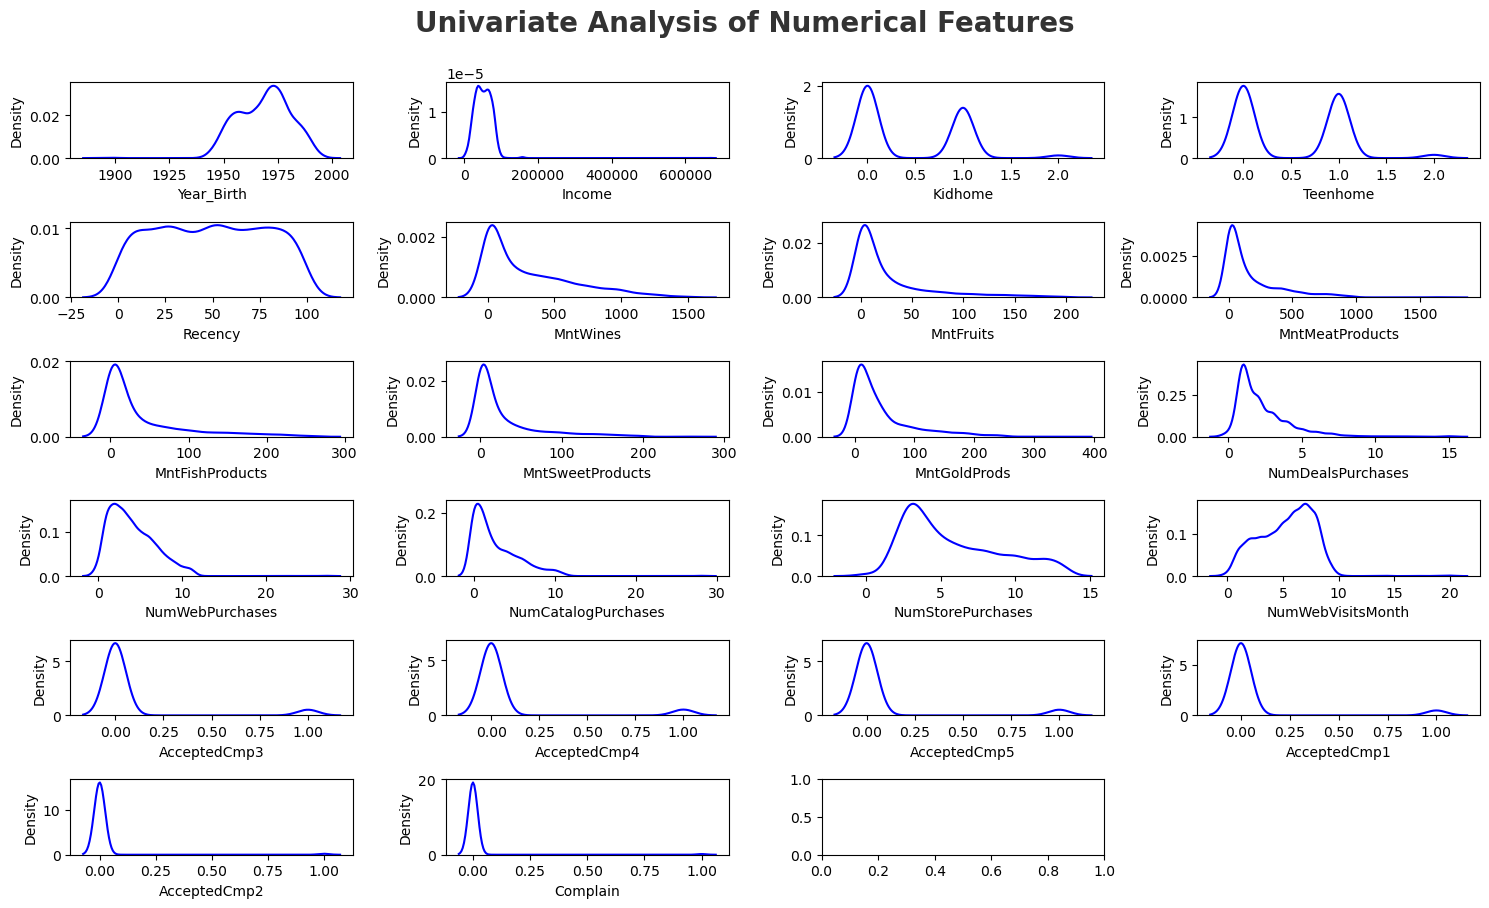

In [18]:
# Univariate Analysis - Numeric features
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(7, 4, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

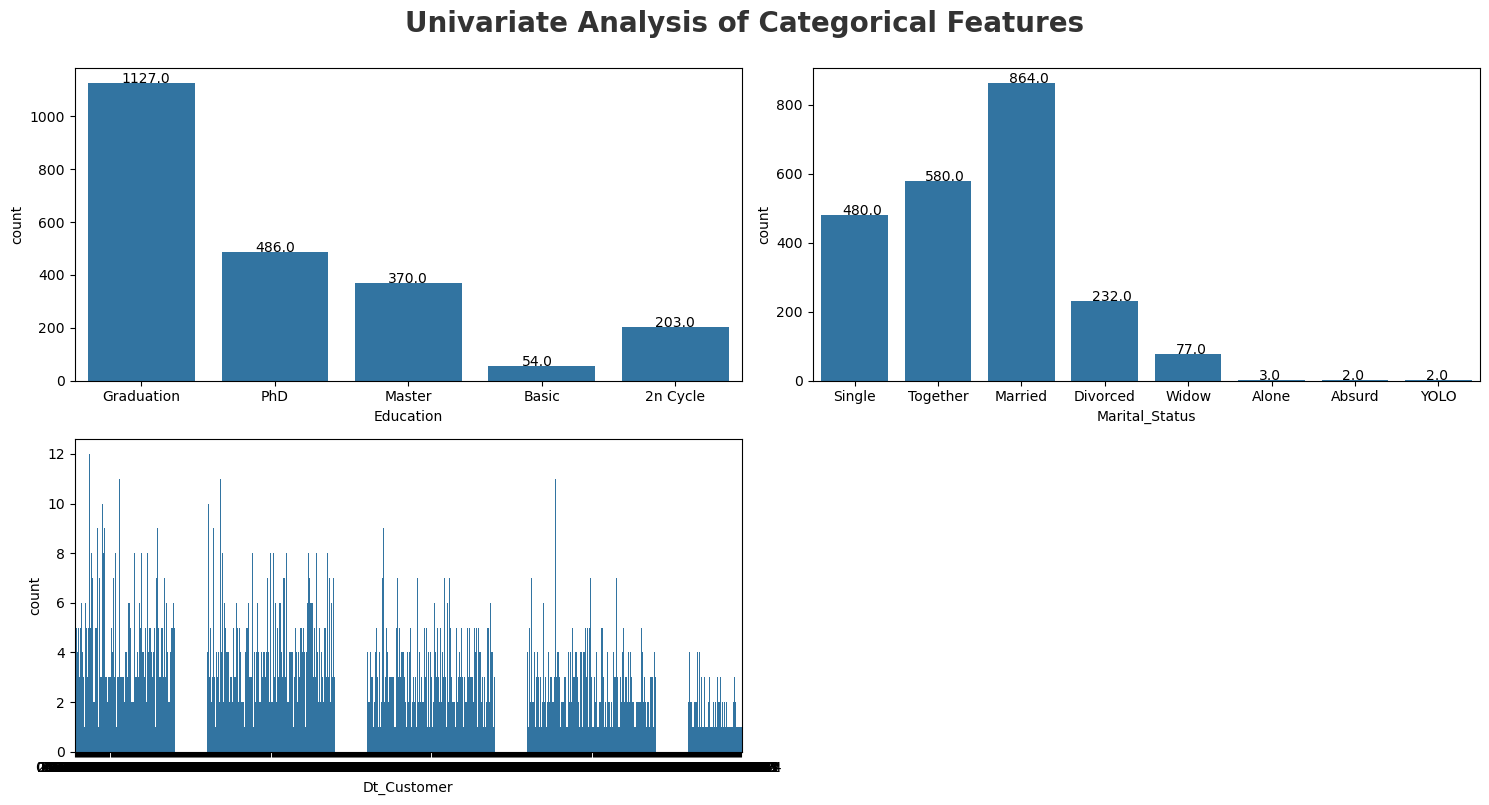

In [20]:
# Univariate Analysis - Categorical features
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(2, 2, i+1)
    ax = sns.countplot(x=df[categorical_features[i]])
    if df[categorical_features[i]].value_counts().count() <10:
        for p in ax.patches:
            ax.annotate('{:.1f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+0.01))
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

In [22]:
#Time Based Analysis
# Count of features based on years 
df1 = df.copy()
df1["Year"] = df1.Dt_Customer.dt.year
customer_joined_per_year = df1.groupby(by="Year", axis=0)[['ID']].count()
customer_joined_per_year = customer_joined_per_year.reset_index()
customer_joined_per_year.columns = ['YEAR','CUSTOMER_JOINED']
sns.barplot(data = customer_joined_per_year, x = customer_joined_per_year['YEAR'], y = customer_joined_per_year['CUSTOMER_JOINED'])

AttributeError: Can only use .dt accessor with datetimelike values

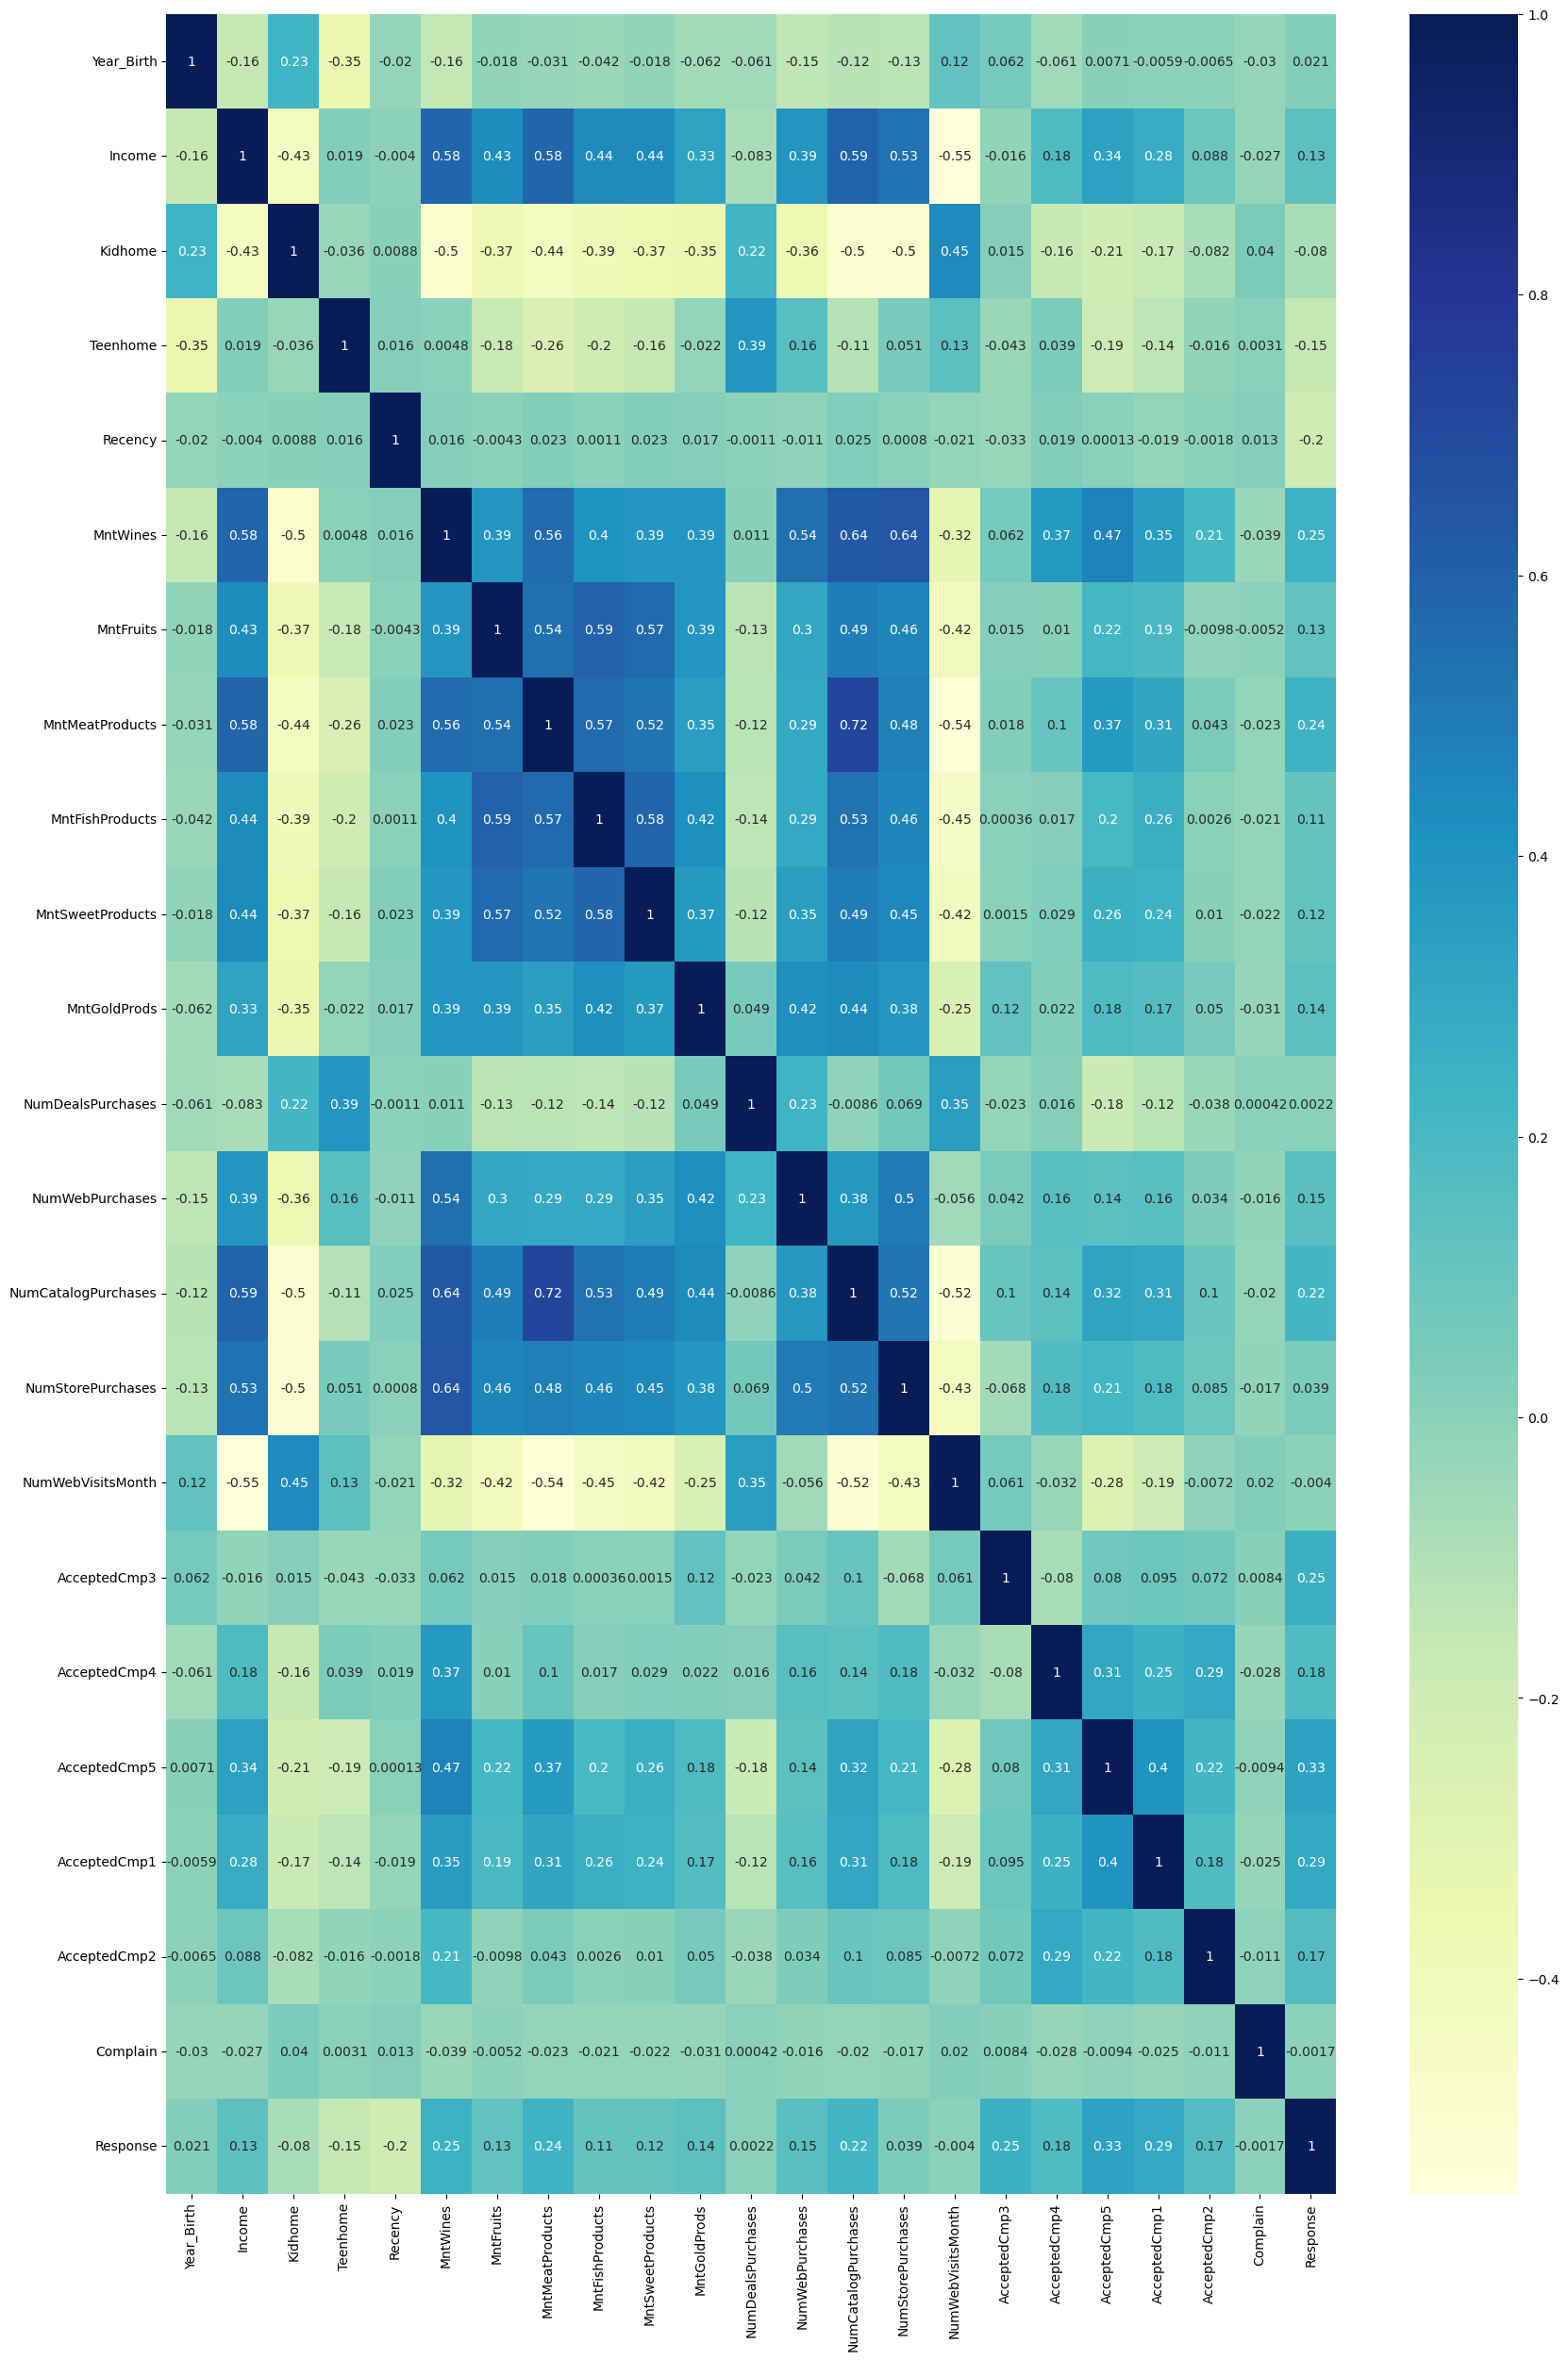

In [24]:
# Check Multicollinearity in Numerical features
plt.figure(figsize = (20,30))
num_features = numeric_features.copy()
num_features.remove('Z_CostContact')
num_features.remove('Z_Revenue')

sns.heatmap(df[num_features].corr(), annot=True, cmap="YlGnBu")
plt.show()

In [26]:
# Filling missing values in the 'Income' column with median income
df['Income'].fillna(df['Income'].median(), inplace=True)

C:\Users\91798\AppData\Local\Temp\ipykernel_11628\1724502549.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [28]:
##9. Visualization of Customer Attributes

In [30]:
# 1. Customer's Age Distribution
df = df[df["Age"] < 90]

#let's plot now
print(f"Let's have a look again on the distribution of customer's age :")

plt.subplots(figsize=(20, 5))
p = sns.histplot(df["Age"],color="#3385ff",kde=True,bins=50,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.set_title("\nCustomer's Age Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAge",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

KeyError: 'Age'

Let's have a look on the distribution of customer's income and spending :


KeyError: "['Total_Spending'] not in index"

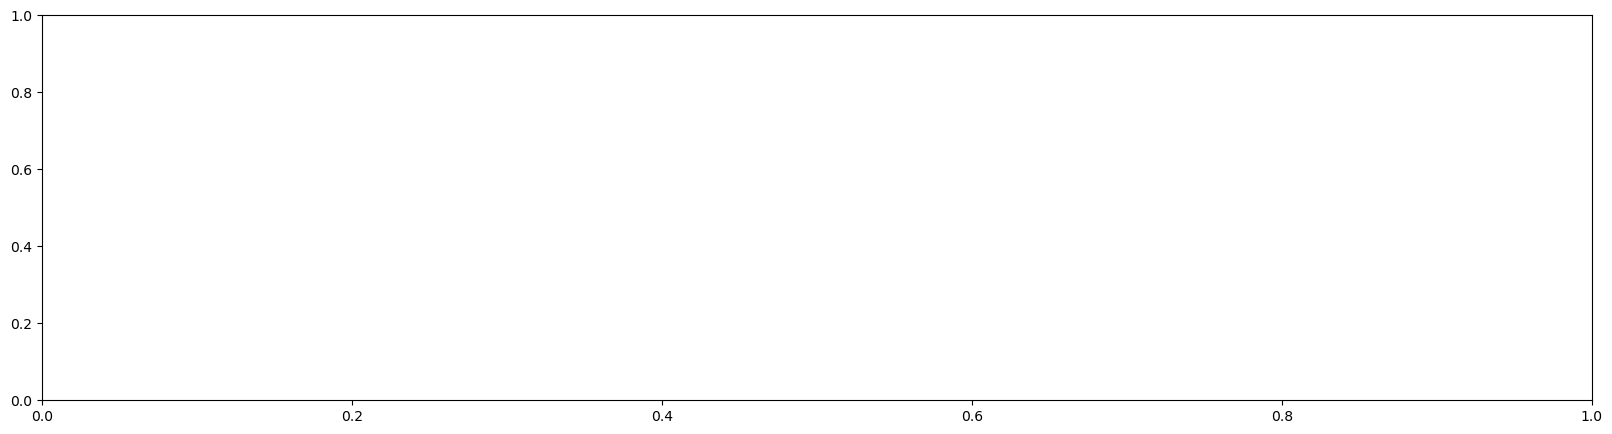

In [32]:
#II. Customer's Income-Spending Distribution
print(f"Let's have a look on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 5))
p = sns.histplot(df[["Total_Spending","Income"]],palette=["#66ffff","#3385ff"],kde=True,bins=30,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()

In [ ]:
#III. Customer's Income-Spending Distribution
df = df[df["Income"] < 600000]

#now, let's plot again
print(f"Let's have a look again on the distribution of customer's income and spending :")
plt.subplots(figsize=(20, 5))
p = sns.histplot(df[["Total_Spending","Income"]],palette=["#66ffff","#3385ff"],kde=True,bins=30,alpha=1,fill=True,edgecolor="black")
p.axes.lines[0].set_color("#101B15")
p.axes.lines[1].set_color("#101B15")
p.axes.set_yscale("symlog")
p.axes.set_title("\nCustomer's Income-Spending Distribution\n",fontsize=25)
plt.ylabel("Count",fontsize=20)
plt.xlabel("\nAmount",fontsize=20)
sns.despine(left=True, bottom=True)

plt.show()